In [ ]:
%%capture
!pip install pmdarima

In [ ]:
import os
import warnings
import itertools
import joblib

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
)

import lightgbm as lgb
import xgboost as xgb
import pmdarima as pm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# FE

In [ ]:
feature_table = pd.read_csv(r"/content/drive/MyDrive/EdTech Project/Code/data/feature/feature_table.csv")
feature_table.shape

(5500, 18)

In [ ]:
feature_table.head()

,code_module,code_presentation,module_presentation_length,historical_student_count,pct_male,pct_higher_ed,total_assignments,is_exam_included,total_learning_materials,day_offset,marketing_spend,marketing_campaign_flag,holiday_flag,semester_start_flag,semester_end_flag,enrollment_num_daily,day_of_week,is_weekend
0,AAA,2013J,268,383,0.610966,0.428198,6,1,413,0,29.15,0,0,1,0,55,0,0
1,AAA,2013J,268,383,0.610966,0.428198,6,1,413,1,31.78,0,0,1,0,57,1,0
2,AAA,2013J,268,383,0.610966,0.428198,6,1,413,2,34.93,0,0,1,0,62,2,0
3,AAA,2013J,268,383,0.610966,0.428198,6,1,413,3,22.00,0,0,1,0,51,3,0
4,AAA,2013J,268,383,0.610966,0.428198,6,1,413,4,21.67,0,0,1,0,87,4,0


In [ ]:
df = feature_table.copy()
TARGET = "enrollment_num_daily"

# -----------------------------
# Create a date from day_offset
# -----------------------------
# Choose the dataset start date (change if known)
start_date = pd.Timestamp("2014-01-01")

df["date"] = start_date + pd.to_timedelta(df["day_offset"], unit="D")

# -----------------------------
# Create a date from day_offset
# -----------------------------
df = pd.get_dummies(df, columns=['code_module'], prefix='module') # module: one-hot

# -----------------------------
# Time Features
# -----------------------------
df["day_of_week"] = df["date"].dt.dayofweek
df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)
df["month"] = df["date"].dt.month
df["quarter"] = df["date"].dt.quarter
df["year"] = df['code_presentation'].str[:4].astype(int)
df['semester'] = df['code_presentation'].str[-1]

df = pd.get_dummies(df, columns=['semester'], prefix='sem') # semester: one-hot
# -----------------------------
# Lag Features
# -----------------------------
df["lag_1"] = df[TARGET].shift(1)
df["lag_7"] = df[TARGET].shift(7)
df["lag_14"] = df[TARGET].shift(14)
df["lag_30"] = df[TARGET].shift(30)

# -----------------------------
# Rolling Features
# -----------------------------
df["rolling_mean_7"] = df[TARGET].rolling(7).mean()
df["rolling_mean_30"] = df[TARGET].rolling(30).mean()
df["rolling_std_30"] = df[TARGET].rolling(30).std()

# -----------------------------
# Rename event columns
# -----------------------------
df.rename(columns={
    "marketing_campaign_flag": "campaign_flag",
    "semester_start_flag": "semester_start"
}, inplace=True)

# Remove rows with NaN created by lag/rolling
df = df.dropna().reset_index(drop=True)
# drop unnecessary cols
df = df.drop(columns=["code_module", "code_presentation"], errors="ignore")

In [ ]:
df['is_exam_included'].value_counts()

,count
is_exam_included,
1,5470


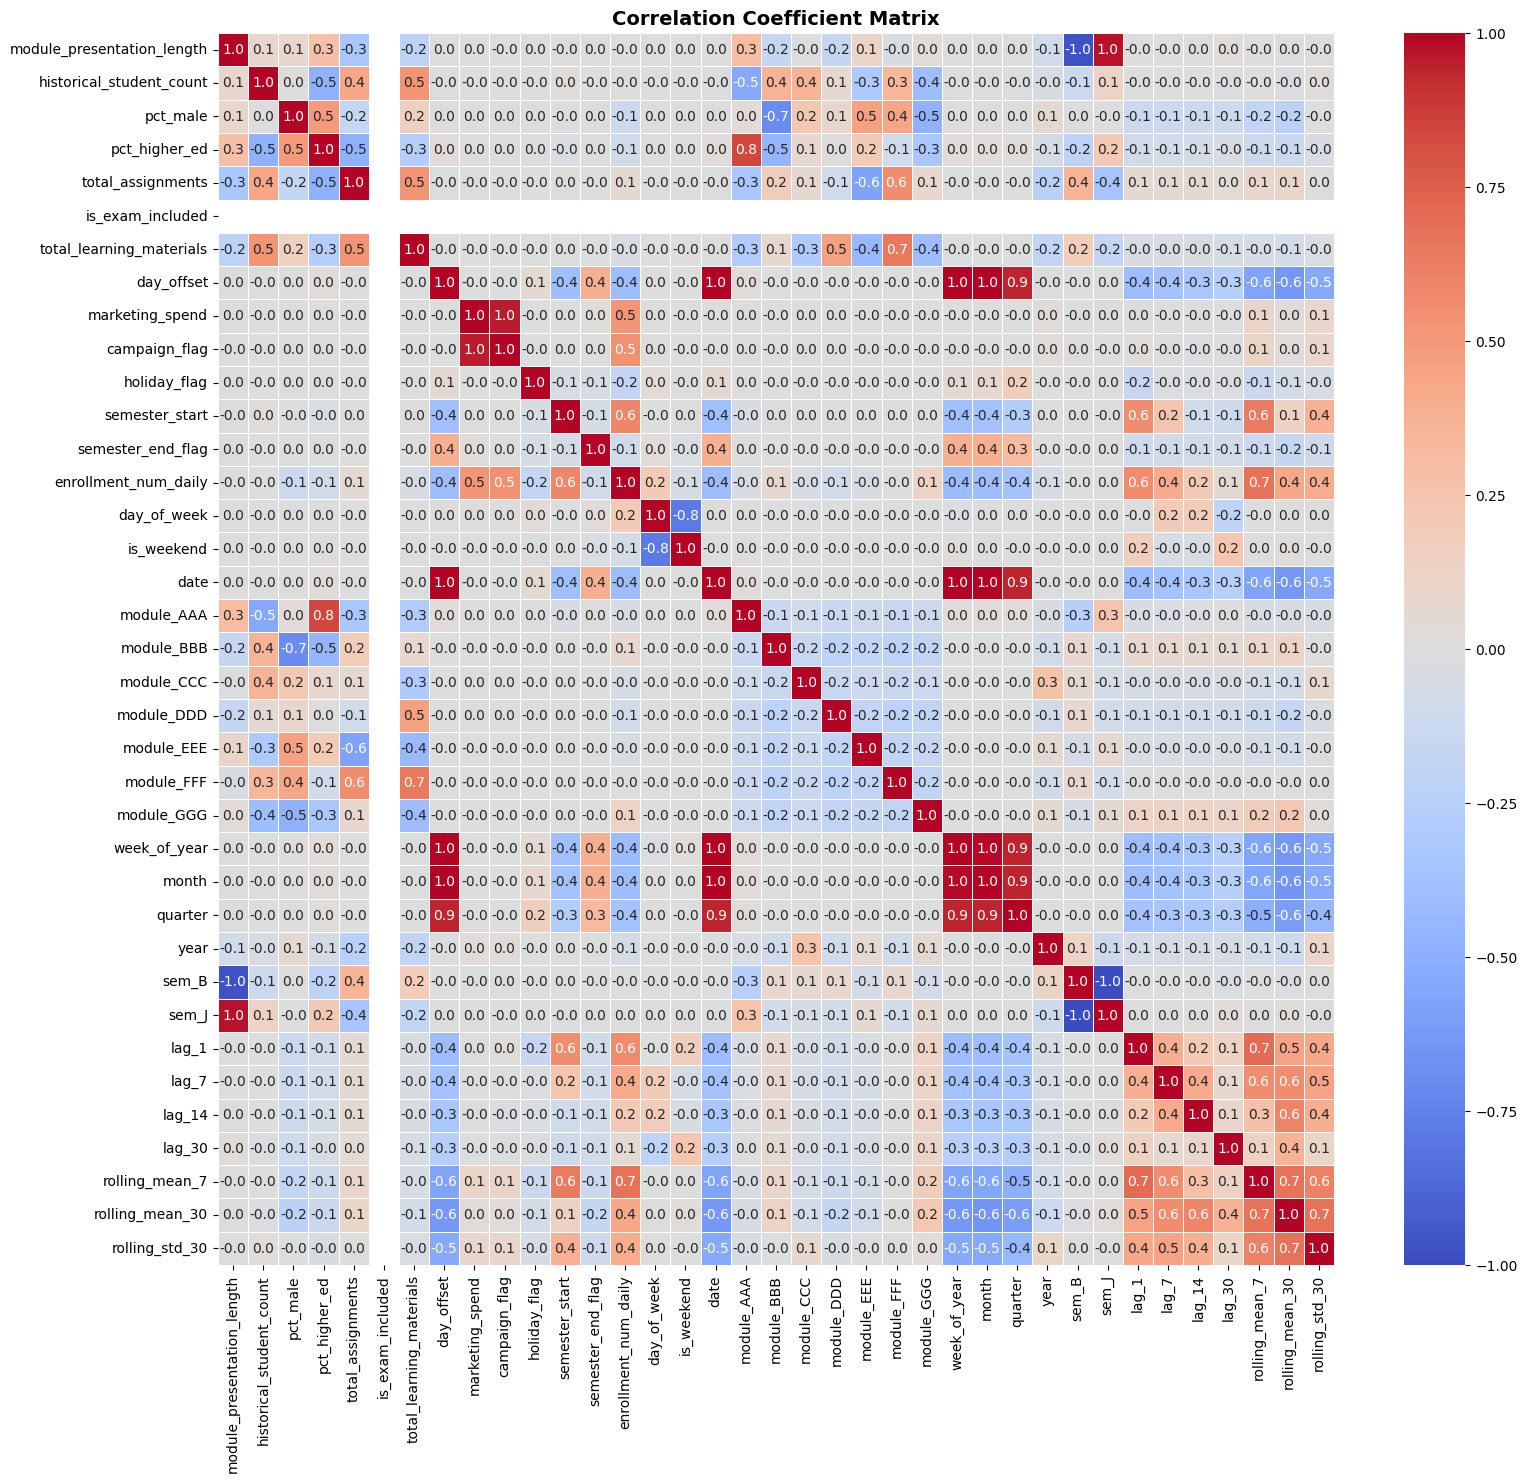

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

matrix = df.corr(method="pearson")

plt.figure(figsize=(18, 16))
sns.heatmap(
    matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".1f",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
)

plt.title("Correlation Coefficient Matrix", fontsize=14, fontweight="bold")
plt.show()


In [ ]:
df = df.drop(columns=["day_offset", "module_presentation_length", 'campaign_flag','is_exam_included','quarter', "date", 'week_of_year'], errors="ignore")

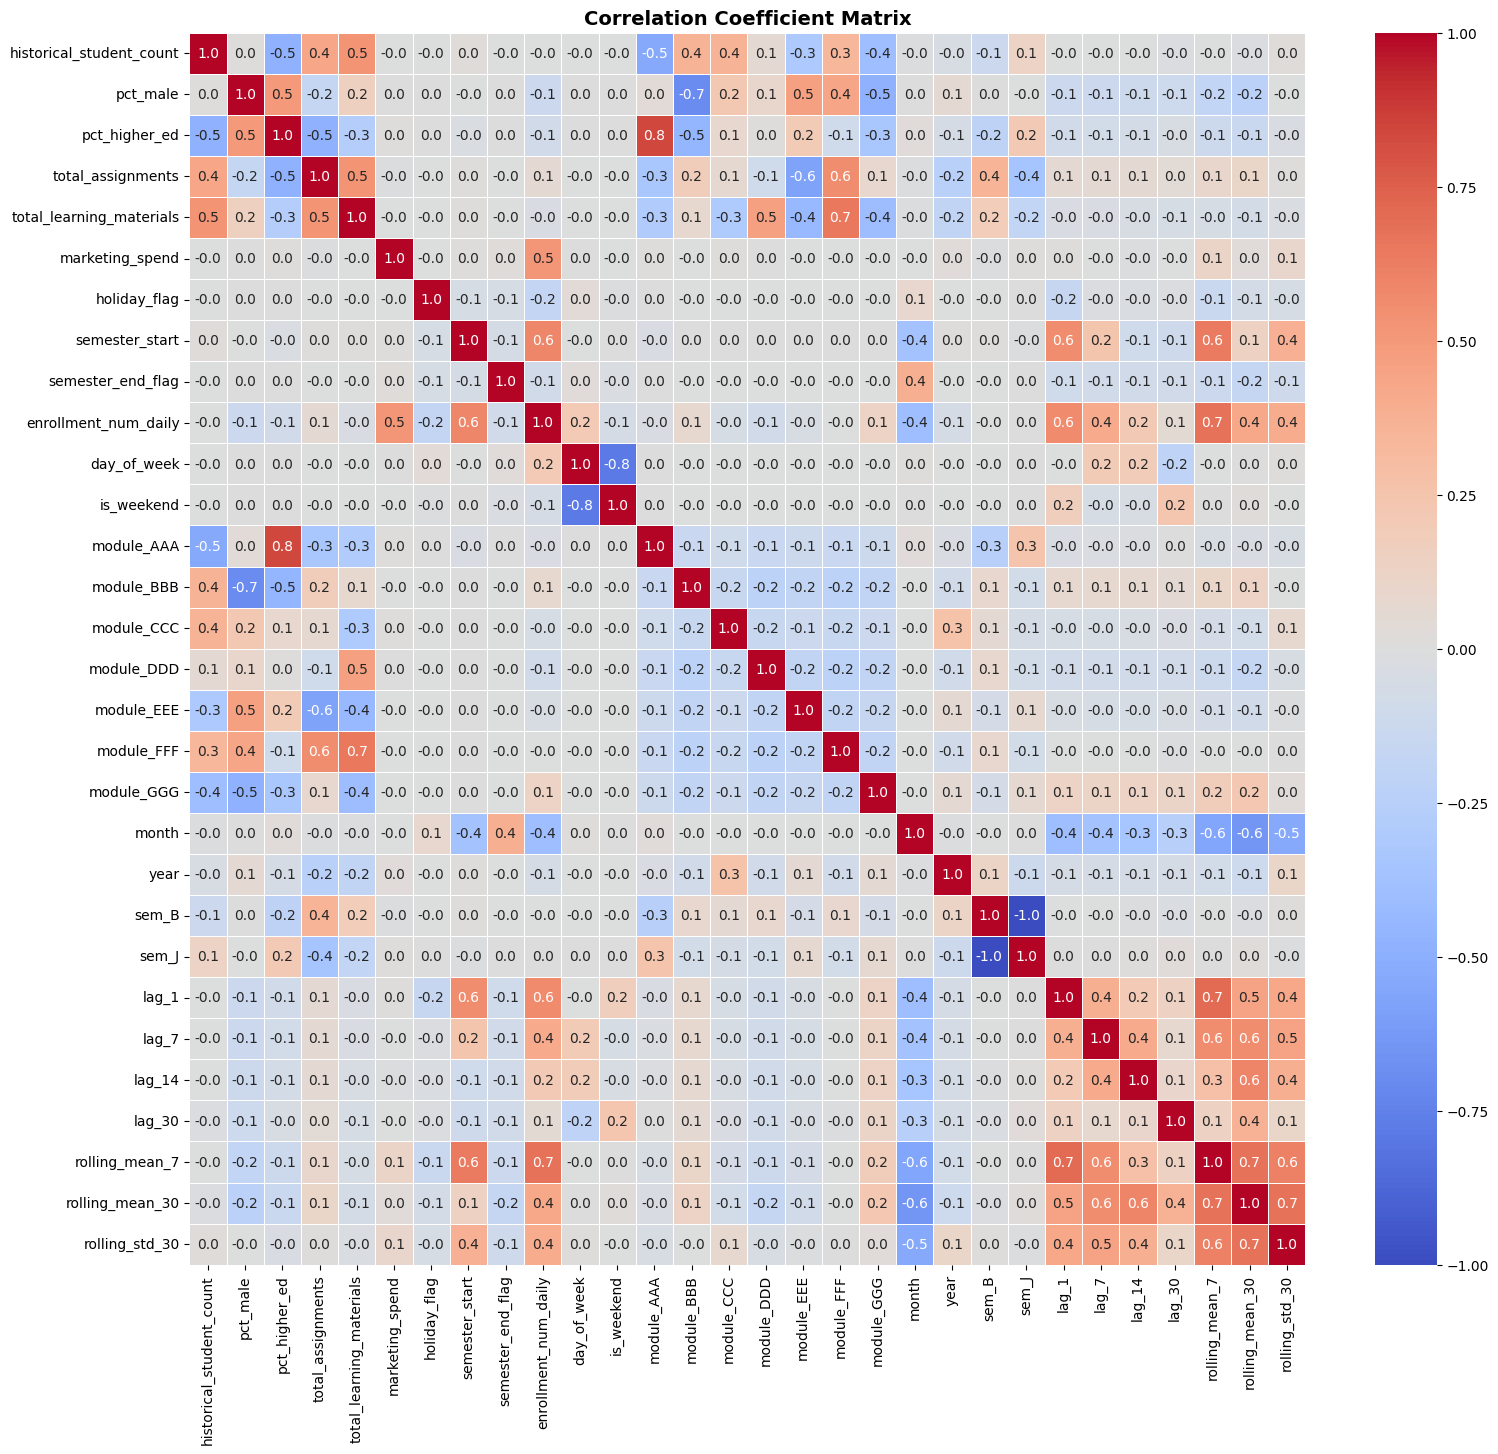

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

matrix = df.corr(method="pearson")

plt.figure(figsize=(18, 16))
sns.heatmap(
    matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".1f",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
)

plt.title("Correlation Coefficient Matrix", fontsize=14, fontweight="bold")
plt.show()


In [ ]:
df.to_csv(r"/content/drive/MyDrive/EdTech Project/Code/data/feature/feature_engineered.csv")

# Config

In [ ]:
LOOK_BACK = 30
N_SPLITS = 5
TEST_SIZE = 30
RANDOM_STATE = 42
CHECKPOINT_DIR = "/content/drive/MyDrive/EdTech Project/Code/checkpoints"
MODEL_DIR = "/content/drive/MyDrive/EdTech Project/Code/saved_models"
SEASON_LENGTH = 7

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

# Train-Test Split

In [ ]:
k = int(len(df) * 0.8)
df = df.iloc[:k]
print(len(df))

4376


In [ ]:
X_raw = df.drop(columns=[TARGET], errors="ignore")
X_raw = pd.get_dummies(X_raw, drop_first=True).astype(float)

y_flat = df[TARGET].values.astype(float)
X_flat = X_raw.values.astype(float)

feature_names = X_raw.columns.tolist()
n_features = X_flat.shape[1]
n_samples = len(df)

In [ ]:
import numpy as np

def walk_forward_splits(n_samples, n_splits=5, test_size=30, min_train_size=None):
    """
    Generate walk-forward (expanding window) pairs (train_idx, test_idx).
    Each fold: train = all data from the beginning to the present, test = the next block.
    """
    if min_train_size is None:
        min_train_size = n_samples - n_splits * test_size

    splits = []
    test_start = min_train_size
    for _ in range(n_splits):
        test_end = test_start + test_size
        if test_end > n_samples:
            break
        train_idx = np.arange(0, test_start)
        test_idx = np.arange(test_start, test_end)
        splits.append((train_idx, test_idx))
        test_start = test_end
    return splits

In [ ]:
tree_splits = walk_forward_splits(n_samples, n_splits=N_SPLITS, test_size=TEST_SIZE)
first_train_idx = tree_splits[0][0]

# Naive

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
import numpy as np


def naive_forecast(y_train, horizon):
    last_value = y_train[-1]
    return np.full(horizon, last_value)

def walk_forward_naive(y, splits):
    fold_metrics = []
    all_true, all_pred = [], []

    for fold, (train_idx, test_idx) in enumerate(splits, 1):
        y_train_fold = y[train_idx]
        horizon = len(test_idx)

        pred = naive_forecast(y_train_fold, horizon)
        true = y[test_idx]

        mae = mean_absolute_error(true, pred)
        rmse = np.sqrt(mean_squared_error(true, pred))
        mape = mean_absolute_percentage_error(true, pred)
        weighted_mape = mean_absolute_percentage_error(true, pred, sample_weight=true)

        fold_metrics.append({"fold": fold, "mae": mae, "rmse": rmse, "mape": mape, "wape": weighted_mape})
        all_true.append(true); all_pred.append(pred)
        print(f"Fold {fold}: MAE={mae:.4f} RMSE={rmse:.4f} MAPE={mape*100:.2f}%, WAPE={weighted_mape*100:.2f}%")

    all_true_flat = np.concatenate(all_true)
    all_pred_flat = np.concatenate(all_pred)
    overall_mape = mean_absolute_percentage_error(all_true_flat, all_pred_flat)
    overall_wape = mean_absolute_percentage_error(all_true_flat, all_pred_flat, sample_weight=all_true_flat)
    print(f"[Naive] Walk-forward overall MAPE: {overall_mape*100:.2f}%")
    print(f"[Naive] Walk-forward overall WAPE: {overall_wape*100:.2f}%")
    return pd.DataFrame(fold_metrics)

# ARIMA/SARIMAX

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings("ignore")
import pmdarima as pm

def select_arima_order(y_train):
    auto_model = pm.auto_arima(
        y_train, seasonal=False,
        start_p=0, start_q=0, max_p=5, max_q=5, max_d=2,
        information_criterion="aic",
        suppress_warnings=True, error_action="ignore",
        stepwise=True,
    )
    return auto_model.order

def walk_forward_arima(y, splits, order=None, refit_order_each_fold=False, label="ARIMA"):
    fold_metrics = []
    all_true, all_pred = [], []
    fixed_order = order

    for fold, (train_idx, test_idx) in enumerate(splits, 1):
        y_train_fold = y[train_idx]
        horizon = len(test_idx)

        current_order = select_arima_order(y_train_fold) if refit_order_each_fold else fixed_order
        model = ARIMA(y_train_fold, order=current_order)
        fitted = model.fit()
        pred = fitted.forecast(steps=horizon)
        true = y[test_idx]

        mae = mean_absolute_error(true, pred)
        rmse = np.sqrt(mean_squared_error(true, pred))
        mape = mean_absolute_percentage_error(true, pred)
        weighted_mape = mean_absolute_percentage_error(true, pred, sample_weight=true)

        fold_metrics.append({"fold": fold, "mae": mae, "rmse": rmse, "mape": mape, "wape": weighted_mape})
        all_true.append(true); all_pred.append(pred)
        print(f"Fold {fold}: MAE={mae:.4f} RMSE={rmse:.4f} MAPE={mape*100:.2f}%, WAPE={weighted_mape*100:.2f}%")

    all_true_flat = np.concatenate(all_true)
    all_pred_flat = np.concatenate(all_pred)
    overall_mape = mean_absolute_percentage_error(all_true_flat, all_pred_flat)
    overall_wape = mean_absolute_percentage_error(all_true_flat, all_pred_flat, sample_weight=all_true_flat)
    print(f"[{label}] Walk-forward overall MAPE: {overall_mape*100:.2f}%")
    print(f"[{label}] Walk-forward overall WAPE: {overall_wape*100:.2f}%")
    return pd.DataFrame(fold_metrics)

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

def select_sarimax_order(y_train, exog_train=None, m=7):
    auto_model = pm.auto_arima(
        y_train, X=exog_train,
        seasonal=True, m=m,
        start_p=0, start_q=0, max_p=3, max_q=3, max_d=2,
        start_P=0, start_Q=0, max_P=2, max_Q=2, max_D=1,
        information_criterion="aic",
        suppress_warnings=True, error_action="ignore",
        stepwise=True,
    )
    return auto_model.order, auto_model.seasonal_order

def walk_forward_sarimax(y, X, splits, order, seasonal_order, use_exog=True, label="SARIMAX"):
    fold_metrics = []
    all_true, all_pred = [], []

    for fold, (train_idx, test_idx) in enumerate(splits, 1):
        y_train_fold = y[train_idx]
        horizon = len(test_idx)

        exog_train = X[train_idx] if use_exog else None
        exog_test = X[test_idx] if use_exog else None

        model = SARIMAX(
            y_train_fold, exog=exog_train,
            order=order, seasonal_order=seasonal_order,
            enforce_stationarity=False, enforce_invertibility=False,
        )
        fitted = model.fit(disp=False)
        pred = fitted.forecast(steps=horizon, exog=exog_test)
        true = y[test_idx]

        mae = mean_absolute_error(true, pred)
        rmse = np.sqrt(mean_squared_error(true, pred))
        mape = mean_absolute_percentage_error(true, pred)
        weighted_mape = mean_absolute_percentage_error(true, pred, sample_weight=true)

        fold_metrics.append({"fold": fold, "mae": mae, "rmse": rmse, "mape": mape, "wape": weighted_mape})
        all_true.append(true); all_pred.append(pred)
        print(f"Fold {fold}: MAE={mae:.4f} RMSE={rmse:.4f} MAPE={mape*100:.2f}%, WAPE={weighted_mape*100:.2f}%")

    all_true_flat = np.concatenate(all_true)
    all_pred_flat = np.concatenate(all_pred)
    overall_mape = mean_absolute_percentage_error(all_true_flat, all_pred_flat)
    overall_wape = mean_absolute_percentage_error(all_true_flat, all_pred_flat, sample_weight=all_true_flat)
    print(f"[{label}] Walk-forward overall MAPE: {overall_mape*100:.2f}%")
    print(f"[{label}] Walk-forward overall WAPE: {overall_wape*100:.2f}%")
    return pd.DataFrame(fold_metrics)

In [ ]:
naive_results = walk_forward_naive(y_flat, tree_splits)

best_arima_order = select_arima_order(y_flat[first_train_idx])
print("\nSelected ARIMA order:", best_arima_order, "\n")
arima_results = walk_forward_arima(y_flat, tree_splits, order=best_arima_order, label="ARIMA")

# scaling exog for SARIMAX to make training more stable
sarimax_scaler = MinMaxScaler()
sarimax_scaler.fit(X_flat[first_train_idx])
X_flat_scaled_for_sarimax = sarimax_scaler.transform(X_flat)

sarimax_order, sarimax_seasonal_order = select_sarimax_order(
    y_flat[first_train_idx],
    exog_train=X_flat_scaled_for_sarimax[first_train_idx],
    m=SEASON_LENGTH,
)
print("\nSelected SARIMAX order:", sarimax_order, sarimax_seasonal_order, "\n")

sarimax_results = walk_forward_sarimax(
    y_flat, X_flat_scaled_for_sarimax, tree_splits,
    order=sarimax_order, seasonal_order=sarimax_seasonal_order, label="SARIMAX",
)

Fold 1: MAE=28.3333 RMSE=31.8496 MAPE=735587939137181056.00%, WAPE=121.36%
Fold 2: MAE=6.6000 RMSE=7.4521 MAPE=180143985094819872.00%, WAPE=63.27%
Fold 3: MAE=7.8667 RMSE=12.0028 MAPE=735587939137181056.00%, WAPE=60.32%
Fold 4: MAE=6.8000 RMSE=8.6448 MAPE=120095990063213280.00%, WAPE=80.33%
Fold 5: MAE=6.4333 RMSE=8.7540 MAPE=120095990063213280.00%, WAPE=89.37%
[Naive] Walk-forward overall MAPE: 378302368699121728.00%
[Naive] Walk-forward overall WAPE: 90.67%

Selected ARIMA order: (5, 0, 3) 

Fold 1: MAE=10.1381 RMSE=13.2197 MAPE=180329218881359136.00%, WAPE=44.26%
Fold 2: MAE=5.9886 RMSE=6.9255 MAPE=425837648718344448.00%, WAPE=51.46%
Fold 3: MAE=9.1333 RMSE=12.4989 MAPE=1273292043863585280.00%, WAPE=61.03%
Fold 4: MAE=6.2738 RMSE=7.0943 MAPE=510266297424018880.00%, WAPE=63.21%
Fold 5: MAE=8.0303 RMSE=8.7062 MAPE=1217718952870788352.00%, WAPE=77.20%
[ARIMA] Walk-forward overall MAPE: 721488832351619200.00%
[ARIMA] Walk-forward overall WAPE: 55.20%

Selected SARIMAX order: (1, 0, 1) (

# XGBoost/LightGBM

In [ ]:
def walk_forward_evaluate(model_fn, X, y, splits, label=""):
    fold_metrics = []
    all_true, all_pred = [], []

    for fold, (train_idx, test_idx) in enumerate(splits, 1):
        model = model_fn()
        model.fit(X[train_idx], y[train_idx])
        pred = model.predict(X[test_idx])

        mae = mean_absolute_error(y[test_idx], pred)
        rmse = np.sqrt(mean_squared_error(y[test_idx], pred))
        mape = mean_absolute_percentage_error(y[test_idx], pred)
        weighted_mape = mean_absolute_percentage_error(y[test_idx], pred, sample_weight=y[test_idx])

        fold_metrics.append({"fold": fold, "mae": mae, "rmse": rmse, "mape": mape, "wape": weighted_mape})
        all_true.append(y[test_idx]); all_pred.append(pred)
        print(f"Fold {fold}: MAE={mae:.4f} RMSE={rmse:.4f} MAPE={mape*100:.2f}%, WAPE={weighted_mape*100:.2f}%")

    all_true_flat = np.concatenate(all_true)
    all_pred_flat = np.concatenate(all_pred)
    overall_mape = mean_absolute_percentage_error(all_true_flat, all_pred_flat)
    overall_wape = mean_absolute_percentage_error(all_true_flat, all_pred_flat, sample_weight=all_true_flat)
    print(f"\n[{label}] Walk-forward overall MAPE: {overall_mape*100:.2f}%")
    print(f"\n[{label}] Walk-forward overall WAPE: {overall_wape*100:.2f}%")
    return pd.DataFrame(fold_metrics)

In [ ]:
import xgboost as xgb

tscv = TimeSeriesSplit(n_splits=5, test_size=30)

xgb_param_grid = {
    "max_depth": [5, 7, 10, 12],
    "learning_rate": [0.01, 0.05],
    "n_estimators": [200, 400, 800],
    "subsample": [0.7, 0.85, 1.0],
    "colsample_bytree": [0.7, 0.85, 1.0],
}

xgb_search = RandomizedSearchCV(
    estimator=xgb.XGBRegressor(random_state=42),
    param_distributions=xgb_param_grid,
    n_iter=20,
    scoring="neg_mean_absolute_percentage_error",
    cv=tscv,
    random_state=42,
    n_jobs=-1,
)
xgb_search.fit(X_flat, y_flat)
print("Best XGBoost params:", xgb_search.best_params_)

xgb_results = walk_forward_evaluate(
    model_fn=lambda: xgb.XGBRegressor(**xgb_search.best_params_, random_state=RANDOM_STATE),
    X=X_flat, y=y_flat, splits=tree_splits, label="XGBoost"
)

Best XGBoost params: {'subsample': 0.85, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
Fold 1: MAE=4.9600 RMSE=6.8088 MAPE=90595914133012480.00%, WAPE=21.63%
Fold 2: MAE=2.6484 RMSE=3.2342 MAPE=141845854774012576.00%, WAPE=23.81%
Fold 3: MAE=2.5256 RMSE=3.3874 MAPE=317597817944145920.00%, WAPE=17.62%
Fold 4: MAE=2.3781 RMSE=2.9131 MAPE=142065146856297856.00%, WAPE=25.36%
Fold 5: MAE=2.2796 RMSE=2.8229 MAPE=253135343677603840.00%, WAPE=24.89%

[XGBoost] Walk-forward overall MAPE: 189048015477014528.00%

[XGBoost] Walk-forward overall WAPE: 22.20%


In [ ]:
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import lightgbm as lgb
import pandas as pd
warnings.filterwarnings("ignore")

# TimeSeriesSplit = walk-forward, used for searching
tscv = TimeSeriesSplit(n_splits=5, test_size=30)

lgb_param_grid = {
    "num_leaves": [15, 31, 63],
    "max_depth": [-1, 5, 10],
    "learning_rate": [0.01, 0.05, 0.1],
    "n_estimators": [200, 400, 800],
    "min_child_samples": [10, 20, 30],
}

lgb_search = RandomizedSearchCV(
    estimator=lgb.LGBMRegressor(random_state=42, verbose=-1),
    param_distributions=lgb_param_grid,
    n_iter=20,
    scoring="neg_mean_absolute_percentage_error",
    cv=tscv,
    random_state=42,
    n_jobs=-1,
)
lgb_search.fit(X_flat, y_flat)
print("Best LightGBM params:", lgb_search.best_params_)

lgb_results = walk_forward_evaluate(
    model_fn=lambda: lgb.LGBMRegressor(**lgb_search.best_params_, random_state=RANDOM_STATE, verbose=-1),
    X=X_flat, y=y_flat, splits=tree_splits, label="LightGBM"
)

Best LightGBM params: {'num_leaves': 31, 'n_estimators': 800, 'min_child_samples': 20, 'max_depth': 10, 'learning_rate': 0.1}
Fold 1: MAE=5.1675 RMSE=7.0376 MAPE=88316528575742032.00%, WAPE=22.60%
Fold 2: MAE=2.9414 RMSE=3.6993 MAPE=63245448350795552.00%, WAPE=28.58%
Fold 3: MAE=2.3639 RMSE=3.0460 MAPE=279056980063647648.00%, WAPE=16.88%
Fold 4: MAE=2.5581 RMSE=3.2940 MAPE=183208723551351296.00%, WAPE=26.45%
Fold 5: MAE=2.3779 RMSE=2.9153 MAPE=195127603312377248.00%, WAPE=28.18%

[LightGBM] Walk-forward overall MAPE: 161791056770782784.00%

[LightGBM] Walk-forward overall WAPE: 23.81%


# LSTM

In [ ]:
split_row_for_scaler = first_train_idx[-1] + 1

X_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()
X_scaler.fit(X_flat[:split_row_for_scaler])
y_scaler.fit(y_flat[:split_row_for_scaler].reshape(-1, 1))

X_scaled = X_scaler.transform(X_flat)
y_scaled = y_scaler.transform(y_flat.reshape(-1, 1))

X_seq, y_seq = [], []
for i in range(LOOK_BACK, len(X_scaled)):
    X_seq.append(X_scaled[i - LOOK_BACK:i])
    y_seq.append(y_scaled[i])
X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

# Sequence k has a target corresponding to the original row (LOOK_BACK + k) -> move the index of tree_splits back to LOOK_BACK
seq_splits = [
    (train_idx[train_idx >= LOOK_BACK] - LOOK_BACK, test_idx - LOOK_BACK)
    for train_idx, test_idx in tree_splits
]


def build_lstm(units1, units2, dropout, lr, look_back, n_features):
    model = Sequential([
        LSTM(units1, return_sequences=True, input_shape=(look_back, n_features)),
        Dropout(dropout),
        LSTM(units2),
        Dropout(dropout),
        Dense(16, activation="relu"),
        Dense(1),
    ])
    model.compile(optimizer=Adam(learning_rate=lr), loss="mse")
    return model

lstm_param_grid = {
    "units1": [32, 64],
    "units2": [16, 32],
    "dropout": [0.2, 0.3],
    "lr": [0.001, 0.0001]
}

In [ ]:
def lstm_walk_forward_search(X_seq, y_seq, splits, param_grid, look_back, n_features,
                              y_scaler, epochs=100, batch_size=32):
    keys, values = zip(*param_grid.items())
    combos = [dict(zip(keys, v)) for v in itertools.product(*values)]
    results = []

    for combo in combos:
        fold_maes = []
        for train_idx, test_idx in splits:
            model = build_lstm(**combo, look_back=look_back, n_features=n_features)
            es = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
            model.fit(
                X_seq[train_idx], y_seq[train_idx], validation_split=0.1,
                epochs=epochs, batch_size=batch_size, callbacks=[es], verbose=0,
            )

            pred = model.predict(X_seq[test_idx], verbose=0)
            y_true_orig = y_scaler.inverse_transform(y_seq[test_idx])
            y_pred_orig = y_scaler.inverse_transform(pred)
            fold_maes.append(mean_absolute_error(y_true_orig, y_pred_orig))

        avg_mae = np.mean(fold_maes)
        results.append({**combo, "avg_mae": avg_mae})
        print(f"{combo} -> avg MAE: {avg_mae:.4f}")

    return pd.DataFrame(results).sort_values("avg_mae").reset_index(drop=True)

In [ ]:
search_splits = seq_splits[:3]
lstm_search_results = lstm_walk_forward_search(
    X_seq, y_seq, search_splits, lstm_param_grid,
    look_back=LOOK_BACK, n_features=n_features, y_scaler=y_scaler,
)
best_lstm_params = lstm_search_results.iloc[0].drop("avg_mae").to_dict()
best_lstm_params["units1"] = int(best_lstm_params["units1"])
best_lstm_params["units2"] = int(best_lstm_params["units2"])

print("Best LSTM params:", best_lstm_params, "\n")

checkpoint = ModelCheckpoint(
    filepath=os.path.join(CHECKPOINT_DIR, "lstm.keras"),
    monitor="val_loss", save_best_only=True, save_weights_only=False, mode="min", verbose=0,
)

lstm_fold_metrics, all_true, all_pred = [], [], []
for fold, (train_idx, test_idx) in enumerate(seq_splits, 1):
    model = build_lstm(**best_lstm_params, look_back=7, n_features=n_features)
    es = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
    model.fit(
        X_seq[train_idx], y_seq[train_idx], validation_split=0.1,
        epochs=100, batch_size=32, callbacks=[es, checkpoint], verbose=0,
    )

    pred = model.predict(X_seq[test_idx], verbose=0)
    y_true_orig = y_scaler.inverse_transform(y_seq[test_idx])
    y_pred_orig = y_scaler.inverse_transform(pred)

    mae = mean_absolute_error(y_true_orig, y_pred_orig)
    rmse = np.sqrt(mean_squared_error(y_true_orig, y_pred_orig))
    mape = mean_absolute_percentage_error(y_true_orig, y_pred_orig)
    weighted_mape = mean_absolute_percentage_error(y_true_orig, y_pred_orig, sample_weight=y_true_orig)

    lstm_fold_metrics.append({"fold": fold, "mae": mae, "rmse": rmse, "mape": mape, "wape": weighted_mape})
    all_true.append(y_true_orig)
    all_pred.append(y_pred_orig)
    print(f"Fold {fold}: MAE={mae:.4f} RMSE={rmse:.4f} MAPE={mape*100:.2f}%, WAPE={weighted_mape*100:.2f}%")

all_true_flat = np.concatenate(all_true)
all_pred_flat = np.concatenate(all_pred)
overall_mape = mean_absolute_percentage_error(all_true_flat, all_pred_flat)
overall_wape = mean_absolute_percentage_error(all_true_flat, all_pred_flat, sample_weight=all_true_flat)
print(f"\n[LSTM] Walk-forward overall MAPE: {overall_mape*100:.2f}%")
print(f"[LSTM] Walk-forward overall WAPE: {overall_wape*100:.2f}%")

lstm_results_df = pd.DataFrame(lstm_fold_metrics)

{'units1': 32, 'units2': 16, 'dropout': 0.2, 'lr': 0.001} -> avg MAE: 8.1018
{'units1': 32, 'units2': 16, 'dropout': 0.2, 'lr': 0.0001} -> avg MAE: 9.8315
{'units1': 32, 'units2': 16, 'dropout': 0.3, 'lr': 0.001} -> avg MAE: 8.8244
{'units1': 32, 'units2': 16, 'dropout': 0.3, 'lr': 0.0001} -> avg MAE: 11.6949
{'units1': 32, 'units2': 32, 'dropout': 0.2, 'lr': 0.001} -> avg MAE: 8.1185
{'units1': 32, 'units2': 32, 'dropout': 0.2, 'lr': 0.0001} -> avg MAE: 13.3342
{'units1': 32, 'units2': 32, 'dropout': 0.3, 'lr': 0.001} -> avg MAE: 7.8342
{'units1': 32, 'units2': 32, 'dropout': 0.3, 'lr': 0.0001} -> avg MAE: 11.2965
{'units1': 64, 'units2': 16, 'dropout': 0.2, 'lr': 0.001} -> avg MAE: 8.7068
{'units1': 64, 'units2': 16, 'dropout': 0.2, 'lr': 0.0001} -> avg MAE: 10.8744
{'units1': 64, 'units2': 16, 'dropout': 0.3, 'lr': 0.001} -> avg MAE: 9.6866
{'units1': 64, 'units2': 16, 'dropout': 0.3, 'lr': 0.0001} -> avg MAE: 9.7071
{'units1': 64, 'units2': 32, 'dropout': 0.2, 'lr': 0.001} -> avg M

# Result and Save

In [ ]:
def summarize_folds(fold_df, label):
    return {
        "model": label,
        "mae": fold_df["mae"].mean(),
        "rmse": fold_df["rmse"].mean(),
        "mape": fold_df["mape"].mean() * 100,
        "wape": fold_df["wape"].mean() * 100,
    }

In [ ]:
summary = pd.DataFrame([
    summarize_folds(naive_results, "Naive"),
    summarize_folds(arima_results, "ARIMA"),
    summarize_folds(sarimax_results, "SARIMAX"),
    summarize_folds(lgb_results, "LightGBM"),
    summarize_folds(xgb_results, "XGBoost"),
    summarize_folds(lstm_results_df, "LSTM"),
]).sort_values("mape").reset_index(drop=True)

print("=" * 50)
print("ALL RESULTS SUMMARY")
print("=" * 50)
print(summary.to_string(index=False))

ALL RESULTS SUMMARY
   model       mae      rmse         mape      wape
LightGBM  3.081742  3.998430 1.617911e+17 24.538211
 XGBoost  2.958321  3.833303 1.890480e+17 22.661907
 SARIMAX  3.727888  4.581623 3.431209e+17 26.138407
   Naive 11.206667 13.740677 3.783024e+17 82.930275
   ARIMA  7.912847  9.688890 7.214888e+17 59.430025
    LSTM  7.326338  8.857674 7.422028e+17 54.848347


In [ ]:
import pickle

final_arima = ARIMA(y_flat, order=best_arima_order).fit()
final_sarimax = SARIMAX(
    y_flat,
    exog=X_flat_scaled_for_sarimax,
    order=sarimax_order,
    seasonal_order=sarimax_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False)

# Lưu model bằng pickle (.pkl)
with open(os.path.join(MODEL_DIR, "lightgbm.pkl"), "wb") as f:
    pickle.dump(lgb_search.best_estimator_, f)

with open(os.path.join(MODEL_DIR, "xgboost.pkl"), "wb") as f:
    pickle.dump(xgb_search.best_estimator_, f)

with open(os.path.join(MODEL_DIR, "arima.pkl"), "wb") as f:
    pickle.dump(final_arima, f)

with open(os.path.join(MODEL_DIR, "sarimax.pkl"), "wb") as f:
    pickle.dump(final_sarimax, f)

with open(os.path.join(MODEL_DIR, "preprocessing.pkl"), "wb") as f:
    pickle.dump(
        {
            "X_scaler": X_scaler,
            "y_scaler": y_scaler,
            "sarimax_scaler": sarimax_scaler,
            "feature_names": feature_names,
            "target": TARGET,
            "look_back": LOOK_BACK,
            "season_length": SEASON_LENGTH,
            "arima_order": best_arima_order,
            "sarimax_order": sarimax_order,
            "sarimax_seasonal_order": sarimax_seasonal_order,
        },
        f
    )

model.save(os.path.join(MODEL_DIR, "lstm.keras"))

with open(os.path.join(MODEL_DIR, "naive_config.pkl"), "wb") as f:
    pickle.dump(
        {"season_length": SEASON_LENGTH, "target": TARGET},
        f
    )

print(f"Saved models and preprocessing artifacts (pkl) to: {MODEL_DIR}")

Saved models and preprocessing artifacts (pkl) to: /content/drive/MyDrive/EdTech Project/Code/saved_models


# XGBoost Analysis

In [ ]:
import joblib

# Load model
loaded_xgb_model = joblib.load(f"{MODEL_DIR}/xgboost.pkl")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": X_raw.columns,
    "Importance": loaded_xgb_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                     Feature  Importance
7             semester_start    0.871510
5            marketing_spend    0.036302
23                     lag_7    0.016495
6               holiday_flag    0.015433
24                    lag_14    0.013921
9                day_of_week    0.009253
26            rolling_mean_7    0.005770
22                     lag_1    0.004703
19                      year    0.004138
27           rolling_mean_30    0.003371
28            rolling_std_30    0.003250
14                module_DDD    0.003105
2              pct_higher_ed    0.001828
3          total_assignments    0.001801
25                    lag_30    0.001568
4   total_learning_materials    0.001435
18                     month    0.001288
1                   pct_male    0.001102
13                module_CCC    0.001088
20                     sem_B    0.000980
8          semester_end_flag    0.000905
0   historical_student_count    0.000755
12                module_BBB    0.000000
10              

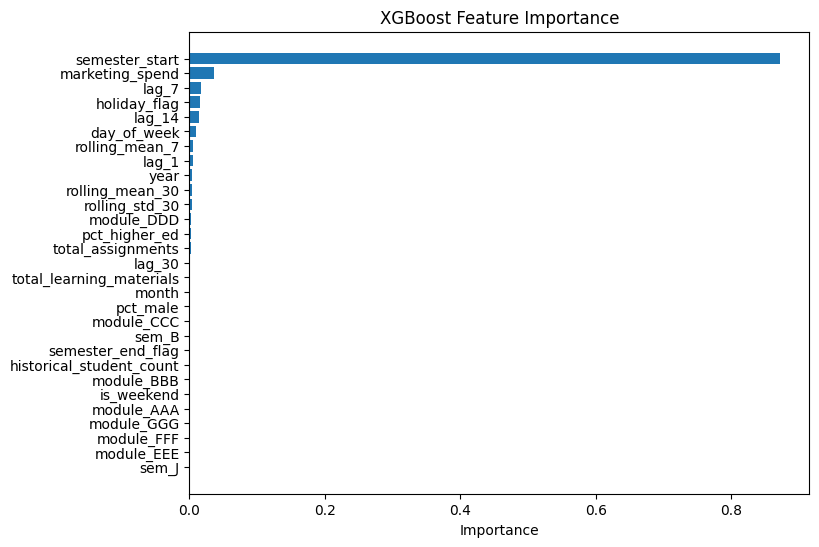

In [ ]:
plt.figure(figsize=(8,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.title("XGBoost Feature Importance")

plt.show()

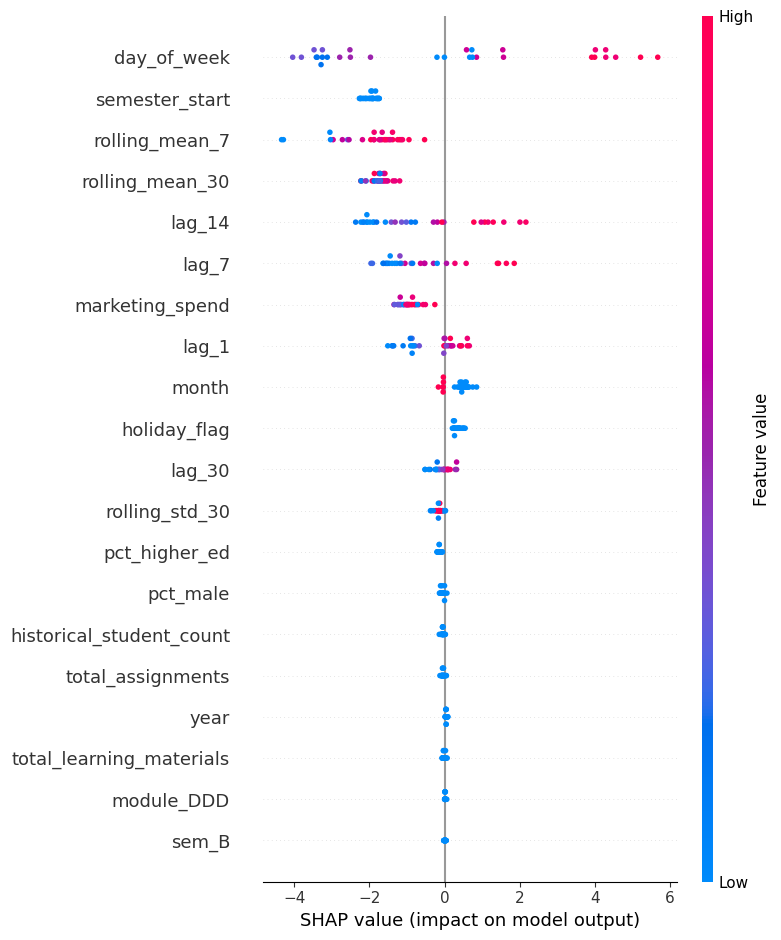

In [ ]:
import shap

explainer = shap.TreeExplainer(loaded_xgb_model)

shap_values = explainer.shap_values(X_raw.iloc[test_idx])

shap.summary_plot(
    shap_values,
    X_raw.iloc[test_idx]
)


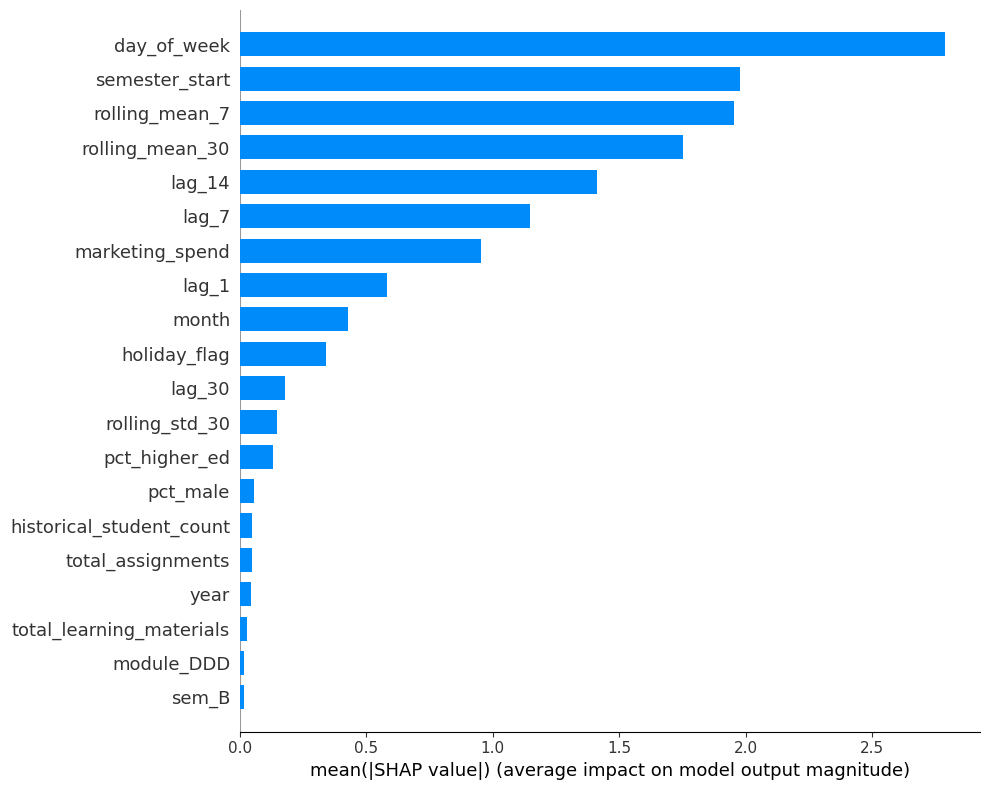

In [ ]:
shap.summary_plot(
    shap_values,
    X_raw.iloc[test_idx],
    plot_type="bar",
    plot_size=(10, 8)
)


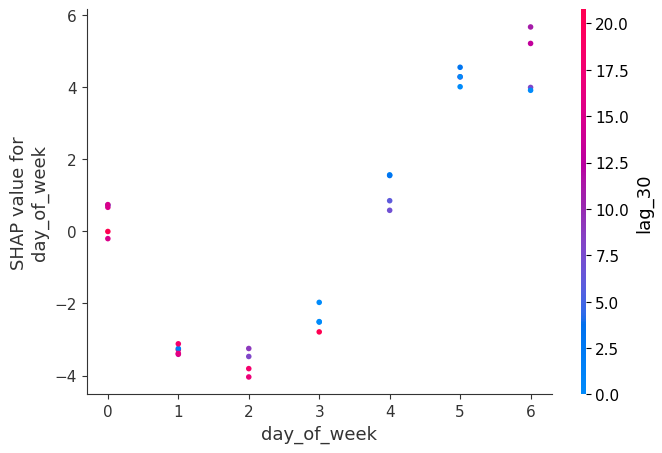

In [ ]:
shap.dependence_plot(
    "day_of_week",
    shap_values,
    X_raw.iloc[test_idx]
)
